# Stage1 → Stage2 Performance Drop Diagnosis

1. **Checkpoint Loading Verification**: Stage1 ckpt를 stage2 모델에 로드 → missing/unexpected keys 확인 (완료: motion 관련 103개만 missing, det/map 정상)
2. **Gradient Conflict Analysis**: Task별 gradient cosine similarity & magnitude 측정
3. **Multi-checkpoint Evaluation**: `dist_test.sh`로 별도 실행

In [1]:
import os
import sys
import torch
import numpy as np
import torch.nn.functional as F
from collections import OrderedDict
from tqdm import tqdm

# ============================================================
# GPU 설정: 2, 3번 GPU 사용
# ============================================================
os.environ['CUDA_VISIBLE_DEVICES'] = '2,3'
GPU_ID = 0  # CUDA_VISIBLE_DEVICES 매핑 후 논리적 0번 = 물리적 2번

# Project root
PROJECT_ROOT = '/home/kyungmin/min_ws/rideflux/HiP-AD'
os.chdir(PROJECT_ROOT)
sys.path.insert(0, PROJECT_ROOT)

# Import mmcv/mmdet + plugin
from mmcv import Config
from mmcv.runner import load_checkpoint, wrap_fp16_model
from mmcv.parallel import MMDataParallel
from mmdet.models import build_detector
from mmdet.datasets import build_dataset
from mmdet.datasets import build_dataloader as build_dataloader_origin
from mmdet.apis import single_gpu_test

# Register custom modules
import importlib
plg_lib = importlib.import_module('projects.mmdet3d_plugin')

print(f"Imports done. Using physical GPU 2,3 (logical {GPU_ID})")
print(f"CUDA available: {torch.cuda.is_available()}, Device count: {torch.cuda.device_count()}")
for i in range(torch.cuda.device_count()):
    print(f"  GPU {i}: {torch.cuda.get_device_name(i)}")

/home/kyungmin/anaconda3/envs/hipad/lib/python3.8/site-packages/mmcv/__init__.py:20: UserWarning: On January 1, 2023, MMCV will release v2.0.0, in which it will remove components related to the training process and add a data transformation module. In addition, it will rename the package names mmcv to mmcv-lite and mmcv-full to mmcv. See https://github.com/open-mmlab/mmcv/blob/master/docs/en/compatibility.md for more details.
  warnings.warn(


Use flash_attn_varlen_kvpacked_func
Imports done. Using physical GPU 2,3 (logical 0)
CUDA available: True, Device count: 2
  GPU 0: NVIDIA GeForce RTX 4090
  GPU 1: NVIDIA GeForce RTX 4090


In [2]:
# ============================================================
# Paths
# ============================================================
STAGE2_CONFIG = os.path.join(PROJECT_ROOT, 'work_dirs/exp/E2_E1_stage2_18ep/E2_E1_stage2_18ep.py')
STAGE1_CKPT   = os.path.join(PROJECT_ROOT, 'work_dirs/hipad_nusc_stage1/latest.pth')

STAGE2_CKPT_DIR = os.path.join(PROJECT_ROOT, 'work_dirs/exp/E2_E1_stage2_18ep')

# 숫자 기준 정렬 (문자열 정렬 X)
STAGE2_ITERS = [2344, 4688, 7032, 9376, 11720, 14064, 16408, 18752, 21096]
STAGE2_CKPTS = [os.path.join(STAGE2_CKPT_DIR, f'iter_{i}.pth') for i in STAGE2_ITERS]

for i, path in zip(STAGE2_ITERS, STAGE2_CKPTS):
    print(f"iter_{i}: exists={os.path.exists(path)}")

print(f"\nConfig: exists={os.path.exists(STAGE2_CONFIG)}")
print(f"Stage1 ckpt: exists={os.path.exists(STAGE1_CKPT)}")

iter_2344: exists=True
iter_4688: exists=True
iter_7032: exists=True
iter_9376: exists=True
iter_11720: exists=True
iter_14064: exists=True
iter_16408: exists=True
iter_18752: exists=True
iter_21096: exists=True

Config: exists=True
Stage1 ckpt: exists=True


## 1. Checkpoint Loading Verification (완료)
- Missing keys: motion 관련 103개만 (motion_anchor, motion_anchor_encoder, motion_refine)
- Unexpected keys: 0개
- Stage1 ckpt on Stage2 model eval: **mAP=0.2089, NDS=0.2820** (stage1 최종 mAP=0.2088, NDS=0.2822와 동일)
- **결론: checkpoint 로딩 정상, 코드 문제 아님**

In [3]:
# ============================================================
# 1-1. Stage1 ckpt를 Stage2 모델에 로드 → weight mismatch 확인
# ============================================================
print("=" * 60)
print("Stage1 checkpoint를 Stage2 모델 구조에 로드합니다...")
print("=" * 60)

cfg = Config.fromfile(STAGE2_CONFIG)
cfg.model.pretrained = None
cfg.model.train_cfg = None

model_s2 = build_detector(cfg.model, test_cfg=cfg.get("test_cfg"))

# load_checkpoint는 missing/unexpected keys를 반환
fp16_cfg = cfg.get("fp16", None)
if fp16_cfg is not None:
    wrap_fp16_model(model_s2)

# strict=False로 로드해서 missing/unexpected keys 확인
ckpt = torch.load(STAGE1_CKPT, map_location="cpu")
if 'state_dict' in ckpt:
    state_dict = ckpt['state_dict']
else:
    state_dict = ckpt

model_keys = set(model_s2.state_dict().keys())
ckpt_keys = set(state_dict.keys())

missing_keys = model_keys - ckpt_keys   # stage2에만 있는 key (새로 추가된 module)
unexpected_keys = ckpt_keys - model_keys  # stage1에만 있는 key (삭제된 module)

print(f"\n총 model params: {len(model_keys)}")
print(f"총 ckpt params: {len(ckpt_keys)}")
print(f"Missing keys (stage2에 새로 추가): {len(missing_keys)}")
print(f"Unexpected keys (stage1에만 있음): {len(unexpected_keys)}")

# Missing keys를 모듈별로 그룹핑
from collections import defaultdict
missing_by_module = defaultdict(list)
for k in sorted(missing_keys):
    module = k.split('.')[0] + '.' + '.'.join(k.split('.')[1:3])
    missing_by_module[module].append(k)

print(f"\n--- Missing keys by module (stage2에서 새로 초기화되는 부분) ---")
for module, keys in sorted(missing_by_module.items()):
    print(f"  {module}: {len(keys)} params")

if unexpected_keys:
    print(f"\n--- Unexpected keys (stage1에만 있는 부분) ---")
    for k in sorted(unexpected_keys)[:20]:
        print(f"  {k}")

del model_s2, ckpt, state_dict
torch.cuda.empty_cache()

Stage1 checkpoint를 Stage2 모델 구조에 로드합니다...


/home/kyungmin/anaconda3/envs/hipad/lib/python3.8/site-packages/mmdet/models/backbones/resnet.py:401: UserWarning: DeprecationWarning: pretrained is deprecated, please use "init_cfg" instead
  warnings.warn('DeprecationWarning: pretrained is deprecated, '



총 model params: 1749
총 ckpt params: 1646
Missing keys (stage2에 새로 추가): 103
Unexpected keys (stage1에만 있음): 0

--- Missing keys by module (stage2에서 새로 초기화되는 부분) ---
  head.onedecoder_head.motion_anchor: 1 params
  head.onedecoder_head.motion_anchor_encoder: 6 params
  head.onedecoder_head.motion_refine: 96 params


## 2. Gradient Conflict Analysis
Stage2 초반 체크포인트(iter_2344, 1epoch)에서 각 task loss의 gradient 방향이 shared parameter에서 얼마나 충돌하는지 측정합니다.

- **Cosine Similarity < 0**: 두 task의 gradient가 반대 방향 → conflict
- **Gradient Magnitude 비교**: 새 task(motion/plan/ego)의 grad가 기존 task(det/map)을 압도하는지

In [4]:
# ============================================================
# 2-1. Training 모드로 모델 + 데이터 준비 (gradient 계산용)
# ============================================================
print("Gradient analysis를 위한 모델/데이터 준비...")

cfg_grad = Config.fromfile(STAGE2_CONFIG)
cfg_grad.model.pretrained = None

# Training config가 필요 (loss 계산을 위해)
model_grad = build_detector(
    cfg_grad.model,
    train_cfg=cfg_grad.get("train_cfg"),
    test_cfg=cfg_grad.get("test_cfg"),
)

fp16_cfg = cfg_grad.get("fp16", None)
if fp16_cfg is not None:
    wrap_fp16_model(model_grad)

# Stage2 초반 체크포인트 로드 (또는 stage1 ckpt 사용)
GRAD_CKPT = STAGE2_CKPTS[0]  # iter_2344 (stage2 초반)
load_checkpoint(model_grad, GRAD_CKPT, map_location="cpu")
model_grad.train()
model_grad = model_grad.cuda(GPU_ID)

# Training dataset 로드 (batch=1로)
train_dataset = build_dataset(cfg_grad.data.train)
train_loader = build_dataloader_origin(
    train_dataset,
    samples_per_gpu=1,
    workers_per_gpu=2,
    dist=False,
    shuffle=False,
)

print(f"Model loaded from: {GRAD_CKPT}")
print(f"Train dataset size: {len(train_dataset)}")
print(f"Tasks: {cfg_grad.task_select}")

Gradient analysis를 위한 모델/데이터 준비...
load checkpoint from local path: /home/kyungmin/min_ws/rideflux/HiP-AD/work_dirs/exp/E2_E1_stage2_18ep/iter_2344.pth
{'version': 'v1.0-trainval'}
Model loaded from: /home/kyungmin/min_ws/rideflux/HiP-AD/work_dirs/exp/E2_E1_stage2_18ep/iter_2344.pth
Train dataset size: 28130
Tasks: ['det', 'map', 'plan', 'ego', 'motion']


In [5]:
# ============================================================
# 2-2. Task별 Loss 분리 + Gradient 계산 함수 정의
# ============================================================
from collections import defaultdict

def get_shared_params(model):
    """Backbone + Neck + Transformer shared layers의 파라미터 목록"""
    shared_params = []
    shared_names = []
    for name, param in model.named_parameters():
        is_shared = any(prefix in name for prefix in [
            'img_backbone', 'img_neck',
            'head.onedecoder_head.layers',
            'head.onedecoder_head.multi_pos_embed',
            'head.onedecoder_head.gnn_',
            'head.onedecoder_head.inter_gnn',
        ])
        if is_shared and param.requires_grad:
            shared_params.append(param)
            shared_names.append(name)
    return shared_params, shared_names


def group_losses_by_task(losses_dict):
    """Loss dict를 task별로 그룹핑"""
    task_losses = {}
    for key, val in losses_dict.items():
        if key.startswith('det_loss') or key.startswith('loss_det'):
            task_losses.setdefault('det', []).append(val)
        elif key.startswith('map_loss') or key.startswith('loss_map'):
            task_losses.setdefault('map', []).append(val)
        elif key.startswith('ego_loss') or key.startswith('loss_ego'):
            task_losses.setdefault('ego', []).append(val)
        elif key.startswith('motion_loss') or key.startswith('loss_motion'):
            task_losses.setdefault('motion', []).append(val)
        elif key.startswith('plan_loss') or key.startswith('loss_plan'):
            task_losses.setdefault('plan', []).append(val)
        elif key.startswith('loss_dense_depth'):
            task_losses.setdefault('depth', []).append(val)
    task_total = {}
    for task, loss_list in task_losses.items():
        task_total[task] = sum(loss_list)
    return task_total


def compute_per_task_gradients(model, losses_dict, shared_params):
    """각 task loss에 대해 shared params의 gradient를 개별 계산"""
    task_losses = group_losses_by_task(losses_dict)
    task_grads = {}
    for task_name, task_loss in task_losses.items():
        model.zero_grad()
        task_loss.backward(retain_graph=True)
        grads = []
        for p in shared_params:
            if p.grad is not None:
                grads.append(p.grad.detach().clone().flatten())
            else:
                grads.append(torch.zeros(p.numel(), device=p.device))
        task_grads[task_name] = torch.cat(grads)
    model.zero_grad()
    return task_grads, task_losses


shared_params, shared_names = get_shared_params(model_grad)
print(f"Shared parameters: {len(shared_params)}")
print(f"Total shared param elements: {sum(p.numel() for p in shared_params):,}")
print(f"Shared module groups:")
module_groups = defaultdict(int)
for name in shared_names:
    group = '.'.join(name.split('.')[:3])
    module_groups[group] += 1
for g, c in sorted(module_groups.items()):
    print(f"  {g}: {c} params")


Shared parameters: 383
Total shared param elements: 49,726,528
Shared module groups:
  head.onedecoder_head.layers: 204 params
  img_backbone.bn1.bias: 1 params
  img_backbone.bn1.weight: 1 params
  img_backbone.conv1.weight: 1 params
  img_backbone.layer1.0: 12 params
  img_backbone.layer1.1: 9 params
  img_backbone.layer1.2: 9 params
  img_backbone.layer2.0: 12 params
  img_backbone.layer2.1: 9 params
  img_backbone.layer2.2: 9 params
  img_backbone.layer2.3: 9 params
  img_backbone.layer3.0: 12 params
  img_backbone.layer3.1: 9 params
  img_backbone.layer3.2: 9 params
  img_backbone.layer3.3: 9 params
  img_backbone.layer3.4: 9 params
  img_backbone.layer3.5: 9 params
  img_backbone.layer4.0: 12 params
  img_backbone.layer4.1: 9 params
  img_backbone.layer4.2: 9 params
  img_neck.fpn_convs.0: 3 params
  img_neck.fpn_convs.1: 3 params
  img_neck.fpn_convs.2: 3 params
  img_neck.fpn_convs.3: 3 params
  img_neck.lateral_convs.0: 2 params
  img_neck.lateral_convs.1: 2 params
  img_neck.

In [6]:
# ============================================================
# 2-3. N개 배치에 대해 gradient conflict 측정
# ============================================================
from mmcv.parallel import MMDataParallel
from mmcv.parallel.scatter_gather import scatter_kwargs

NUM_BATCHES = 10  # 측정할 배치 수

all_cos_sims = defaultdict(list)
all_grad_norms = defaultdict(list)
all_task_loss_vals = defaultdict(list)

# MMDataParallel로 감싸서 DataContainer scatter 처리
model_dp = MMDataParallel(model_grad, device_ids=[GPU_ID])
model_dp.train()

print(f"Gradient conflict analysis over {NUM_BATCHES} batches...")
print("-" * 60)

for batch_idx, data in enumerate(train_loader):
    if batch_idx >= NUM_BATCHES:
        break

    # MMDataParallel의 scatter로 DataContainer → GPU tensor 변환
    scatter_input, scatter_kwargs_out = scatter_kwargs(
        inputs=None, kwargs=data, target_gpus=[GPU_ID]
    )
    data_gpu = scatter_kwargs_out[0]

    # img를 꺼내고 나머지를 kwargs로
    img = data_gpu.pop('img')

    # Forward (training mode) — fp32로 실행 (half/float mismatch 방지)
    losses = model_grad.forward_train(img.float(), **data_gpu)

    # Loss values 기록
    print(f"\nBatch {batch_idx}:")
    task_totals = group_losses_by_task(losses)
    for task, loss_val in sorted(task_totals.items()):
        val = loss_val.item()
        all_task_loss_vals[task].append(val)
        print(f"  {task}_loss = {val:.4f}")

    # Per-task gradient 계산
    task_grads, _ = compute_per_task_gradients(model_grad, losses, shared_params)

    # Gradient norm
    for task, grad in task_grads.items():
        norm = grad.float().norm().item()
        all_grad_norms[task].append(norm)

    # Pairwise cosine similarity
    tasks = sorted(task_grads.keys())
    for i in range(len(tasks)):
        for j in range(i + 1, len(tasks)):
            g_i = task_grads[tasks[i]].float().unsqueeze(0)
            g_j = task_grads[tasks[j]].float().unsqueeze(0)
            cos = F.cosine_similarity(g_i, g_j).item()
            pair = f"{tasks[i]} vs {tasks[j]}"
            all_cos_sims[pair].append(cos)

    # 메모리 정리
    del losses, task_grads, data_gpu, img
    torch.cuda.empty_cache()

print("\n" + "=" * 60)
print("Done collecting gradient stats.")

Gradient conflict analysis over 10 batches...
------------------------------------------------------------

Batch 0:
  depth_loss = 1.7906
  det_loss = 18.0569
  ego_loss = 0.0000
  map_loss = 7.4876
  motion_loss = 0.8018
  plan_loss = 1.5905

Batch 1:
  depth_loss = 1.5776
  det_loss = 16.3455
  ego_loss = 0.0000
  map_loss = 7.3318
  motion_loss = 0.7516
  plan_loss = 1.9304

Batch 2:
  depth_loss = 1.3950
  det_loss = 15.0142
  ego_loss = 0.0000
  map_loss = 7.2875
  motion_loss = 0.4804
  plan_loss = 1.9315

Batch 3:
  depth_loss = 1.6285
  det_loss = 16.6311
  ego_loss = 0.0000
  map_loss = 7.4644
  motion_loss = 1.5402
  plan_loss = 1.6137

Batch 4:
  depth_loss = 1.4515
  det_loss = 17.0457
  ego_loss = 0.0000
  map_loss = 6.3544
  motion_loss = 1.6893
  plan_loss = 1.8812

Batch 5:
  depth_loss = 1.9061
  det_loss = 17.6244
  ego_loss = 0.0000
  map_loss = 5.9255
  motion_loss = 1.4464
  plan_loss = 2.1542

Batch 6:
  depth_loss = 1.6697
  det_loss = 17.1110
  ego_loss = 0.000

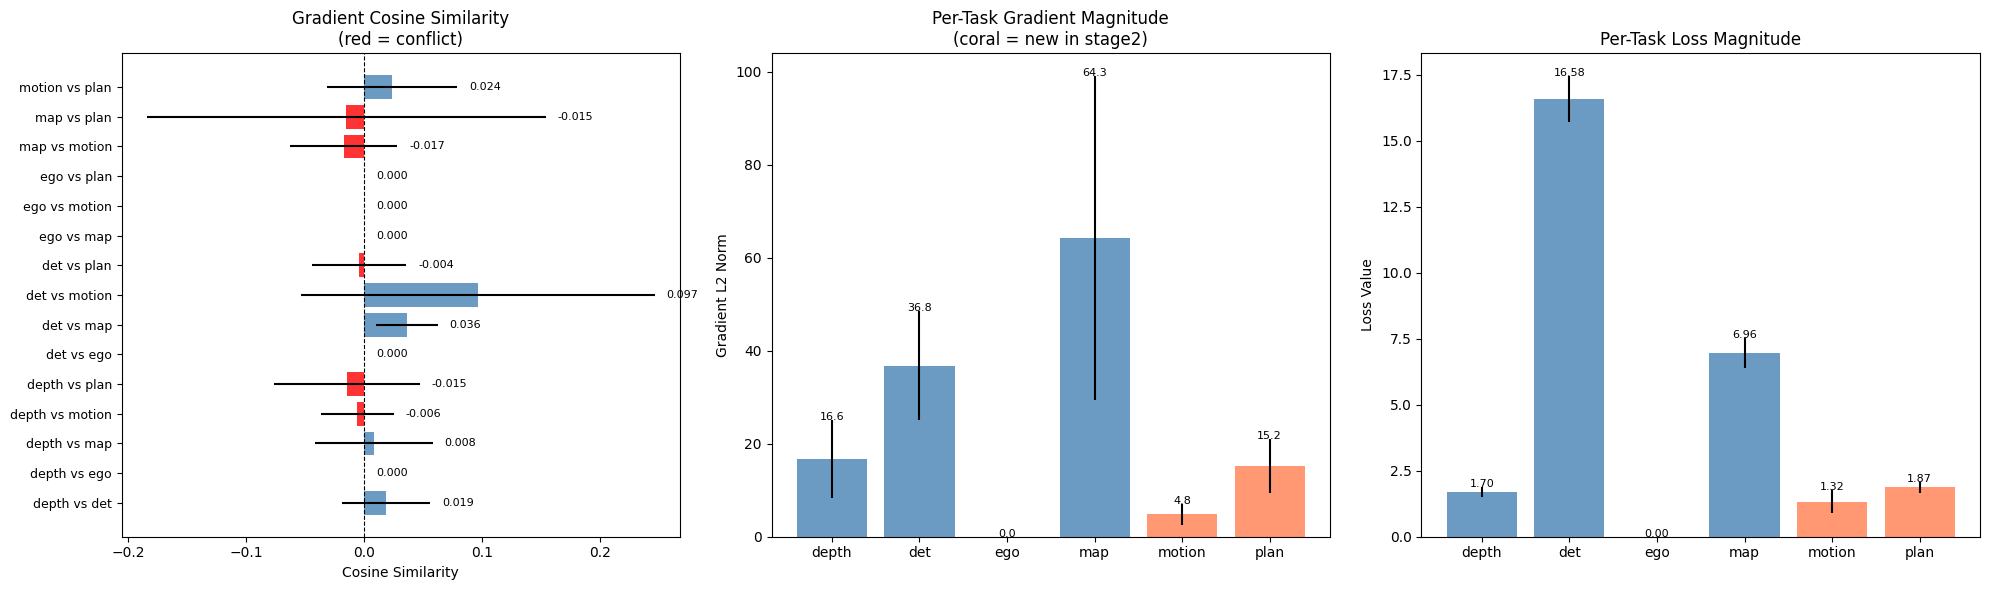


GRADIENT CONFLICT SUMMARY

Task Pair                 Cos Sim (mean±std)        Conflict?
------------------------------------------------------------
depth vs det              +0.0190 ± 0.0374       No
depth vs ego              +0.0000 ± 0.0000       No
depth vs map              +0.0082 ± 0.0500       No
depth vs motion           -0.0057 ± 0.0308       ⚠️  YES
depth vs plan             -0.0145 ± 0.0622       ⚠️  YES
det vs ego                +0.0000 ± 0.0000       No
det vs map                +0.0364 ± 0.0261       No
det vs motion             +0.0966 ± 0.1499       No
det vs plan               -0.0042 ± 0.0402       ⚠️  YES
ego vs map                +0.0000 ± 0.0000       No
ego vs motion             +0.0000 ± 0.0000       No
ego vs plan               +0.0000 ± 0.0000       No
map vs motion             -0.0171 ± 0.0453       ⚠️  YES
map vs plan               -0.0149 ± 0.1691       ⚠️  YES
motion vs plan            +0.0238 ± 0.0554       No

Task            Grad Norm (mean)     Loss V

In [7]:
# ============================================================
# 2-4. Gradient Conflict 결과 시각화
# ============================================================
import matplotlib.pyplot as plt
import pandas as pd

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# --- (A) Gradient Cosine Similarity ---
ax = axes[0]
pairs = sorted(all_cos_sims.keys())
means = [np.mean(all_cos_sims[p]) for p in pairs]
stds = [np.std(all_cos_sims[p]) for p in pairs]
colors = ['red' if m < 0 else 'steelblue' for m in means]

bars = ax.barh(range(len(pairs)), means, xerr=stds, color=colors, alpha=0.8)
ax.set_yticks(range(len(pairs)))
ax.set_yticklabels(pairs, fontsize=9)
ax.axvline(x=0, color='black', linestyle='--', linewidth=0.8)
ax.set_xlabel('Cosine Similarity')
ax.set_title('Gradient Cosine Similarity\n(red = conflict)')
for i, (m, s) in enumerate(zip(means, stds)):
    ax.text(m + s + 0.01, i, f'{m:.3f}', va='center', fontsize=8)

# --- (B) Gradient Magnitude ---
ax = axes[1]
tasks = sorted(all_grad_norms.keys())
task_means = [np.mean(all_grad_norms[t]) for t in tasks]
task_stds = [np.std(all_grad_norms[t]) for t in tasks]

# 새 task와 기존 task 색상 구분
task_colors = ['coral' if t in ['motion', 'plan', 'ego'] else 'steelblue' for t in tasks]
ax.bar(tasks, task_means, yerr=task_stds, color=task_colors, alpha=0.8)
ax.set_ylabel('Gradient L2 Norm')
ax.set_title('Per-Task Gradient Magnitude\n(coral = new in stage2)')
for i, (m, s) in enumerate(zip(task_means, task_stds)):
    ax.text(i, m + s, f'{m:.1f}', ha='center', fontsize=8)

# --- (C) Task Loss Values ---
ax = axes[2]
tasks = sorted(all_task_loss_vals.keys())
loss_means = [np.mean(all_task_loss_vals[t]) for t in tasks]
loss_stds = [np.std(all_task_loss_vals[t]) for t in tasks]
task_colors = ['coral' if t in ['motion', 'plan', 'ego'] else 'steelblue' for t in tasks]
ax.bar(tasks, loss_means, yerr=loss_stds, color=task_colors, alpha=0.8)
ax.set_ylabel('Loss Value')
ax.set_title('Per-Task Loss Magnitude')
for i, (m, s) in enumerate(zip(loss_means, loss_stds)):
    ax.text(i, m + s, f'{m:.2f}', ha='center', fontsize=8)

plt.tight_layout()
plt.savefig(os.path.join(STAGE2_CKPT_DIR, 'gradient_conflict_analysis.png'), dpi=150, bbox_inches='tight')
plt.show()

# 요약 테이블
print("\n" + "=" * 60)
print("GRADIENT CONFLICT SUMMARY")
print("=" * 60)
print(f"\n{'Task Pair':<25} {'Cos Sim (mean±std)':<25} {'Conflict?'}")
print("-" * 60)
for pair in sorted(all_cos_sims.keys()):
    m = np.mean(all_cos_sims[pair])
    s = np.std(all_cos_sims[pair])
    conflict = "⚠️  YES" if m < 0 else "No"
    print(f"{pair:<25} {m:+.4f} ± {s:.4f}       {conflict}")

print(f"\n{'Task':<15} {'Grad Norm (mean)':<20} {'Loss Value (mean)'}")
print("-" * 50)
for task in sorted(all_grad_norms.keys()):
    gn = np.mean(all_grad_norms[task])
    lv = np.mean(all_task_loss_vals.get(task, [0]))
    print(f"{task:<15} {gn:.4f}            {lv:.4f}")

In [8]:
# Gradient analysis 메모리 정리
del model_grad, train_dataset, train_loader
torch.cuda.empty_cache()
print("Gradient analysis memory cleared.")

Gradient analysis memory cleared.


## 3. Fine-grained Gradient Conflict Analysis (Layer Group별)

공유 레이어를 4개 그룹으로 나눠서 gradient conflict를 측정합니다.

| Group | 레이어 | 공유 수준 |
|-------|--------|-----------|
| **A. backbone+neck** | img_backbone, img_neck | 전체 공유, task head에서 먼 위치 |
| **B. decoder norm+ffn** | layers[] 중 norm(12개), ffn(6개) | 모든 task 쿼리 concat 상태에서 동일 weight 적용 — 핵심 |
| **C. fc_before + fc_after** | decouple_attn projection | 전체 공유 |
| **D. inter_gnn** | layers[] 중 inter_gnn(6개) | plan/ego → det/map 단방향 cross-attention |

각 그룹을 **iter_2344(1ep), iter_4688(2ep), iter_7032(3ep)** 3개 체크포인트에서 측정합니다.

In [9]:
# ============================================================
# 3-0. 공통 유틸리티 + 모델/데이터 준비 함수
# ============================================================
NUM_BATCHES = 10
CKPT_ITERS = [2344, 4688, 7032]  # 1ep, 2ep, 3ep
CKPT_PATHS = {it: os.path.join(STAGE2_CKPT_DIR, f'iter_{it}.pth') for it in CKPT_ITERS}

# operation_order에서 각 op의 indices (0-based)
OPERATION_ORDER = [
    'concat', 'gnn', 'inter_gnn', 'norm', 'split', 'deformable',
    'concat', 'ffn', 'norm', 'split', 'refine',
    'concat', 'temp_gnn', 'gnn', 'inter_gnn', 'norm', 'split', 'deformable',
    'concat', 'ffn', 'norm', 'split', 'refine',
    'concat', 'temp_gnn', 'gnn', 'inter_gnn', 'norm', 'split', 'deformable',
    'concat', 'ffn', 'norm', 'split', 'refine',
    'concat', 'temp_gnn', 'gnn', 'inter_gnn', 'norm', 'split', 'deformable',
    'concat', 'ffn', 'norm', 'split', 'refine',
    'concat', 'temp_gnn', 'gnn', 'inter_gnn', 'norm', 'split', 'deformable',
    'concat', 'ffn', 'norm', 'split', 'refine',
    'concat', 'temp_gnn', 'gnn', 'inter_gnn', 'norm', 'split', 'deformable',
    'concat', 'ffn', 'norm', 'split', 'refine',
]

NORM_INDICES = [i for i, op in enumerate(OPERATION_ORDER) if op == 'norm']
FFN_INDICES = [i for i, op in enumerate(OPERATION_ORDER) if op == 'ffn']
INTER_GNN_INDICES = [i for i, op in enumerate(OPERATION_ORDER) if op == 'inter_gnn']

print(f"norm indices ({len(NORM_INDICES)}): {NORM_INDICES}")
print(f"ffn indices ({len(FFN_INDICES)}): {FFN_INDICES}")
print(f"inter_gnn indices ({len(INTER_GNN_INDICES)}): {INTER_GNN_INDICES}")


def build_model_and_loader(ckpt_path):
    """모델 + 데이터로더 생성 (training mode)"""
    cfg_g = Config.fromfile(STAGE2_CONFIG)
    cfg_g.model.pretrained = None
    model = build_detector(cfg_g.model, train_cfg=cfg_g.get("train_cfg"), test_cfg=cfg_g.get("test_cfg"))
    fp16_cfg = cfg_g.get("fp16", None)
    if fp16_cfg is not None:
        wrap_fp16_model(model)
    load_checkpoint(model, ckpt_path, map_location="cpu")
    model.train()
    model = model.cuda(GPU_ID)

    dataset = build_dataset(cfg_g.data.train)
    loader = build_dataloader_origin(dataset, samples_per_gpu=1, workers_per_gpu=2, dist=False, shuffle=False)
    return model, loader


def get_params_by_filter(model, filter_fn):
    """filter_fn(name) -> bool 인 파라미터만 수집"""
    params, names = [], []
    for name, param in model.named_parameters():
        if filter_fn(name) and param.requires_grad:
            params.append(param)
            names.append(name)
    return params, names


def compute_gradient_conflict(model, loader, target_params, num_batches=NUM_BATCHES):
    """target_params에 대해 task별 gradient conflict 측정"""
    all_cos_sims = defaultdict(list)
    all_grad_norms = defaultdict(list)
    all_task_loss_vals = defaultdict(list)

    for batch_idx, data in enumerate(loader):
        if batch_idx >= num_batches:
            break

        scatter_input, scatter_kwargs_out = scatter_kwargs(
            inputs=None, kwargs=data, target_gpus=[GPU_ID]
        )
        data_gpu = scatter_kwargs_out[0]
        img = data_gpu.pop('img')

        losses = model.forward_train(img.float(), **data_gpu)
        task_losses = group_losses_by_task(losses)

        for task, loss_val in task_losses.items():
            all_task_loss_vals[task].append(loss_val.item())

        # Task별 gradient 계산
        task_grads = {}
        for task_name, task_loss in task_losses.items():
            model.zero_grad()
            task_loss.backward(retain_graph=True)
            grads = []
            for p in target_params:
                if p.grad is not None:
                    grads.append(p.grad.detach().clone().flatten())
                else:
                    grads.append(torch.zeros(p.numel(), device=p.device))
            task_grads[task_name] = torch.cat(grads)
        model.zero_grad()

        for task, grad in task_grads.items():
            all_grad_norms[task].append(grad.float().norm().item())

        tasks = sorted(task_grads.keys())
        for i in range(len(tasks)):
            for j in range(i + 1, len(tasks)):
                g_i = task_grads[tasks[i]].float().unsqueeze(0)
                g_j = task_grads[tasks[j]].float().unsqueeze(0)
                cos = F.cosine_similarity(g_i, g_j).item()
                pair = f"{tasks[i]} vs {tasks[j]}"
                all_cos_sims[pair].append(cos)

        del losses, task_grads, task_losses, data_gpu, img
        torch.cuda.empty_cache()

        if (batch_idx + 1) % 5 == 0:
            print(f"  batch {batch_idx + 1}/{num_batches} done")

    return dict(all_cos_sims), dict(all_grad_norms), dict(all_task_loss_vals)


def print_conflict_summary(cos_sims, grad_norms, group_name):
    """결과 요약 출력"""
    print(f"\n--- {group_name} ---")
    print(f"{'Task Pair':<25} {'Cos Sim (mean +/- std)':<25} {'Conflict?'}")
    print("-" * 60)
    for pair in sorted(cos_sims.keys()):
        m = np.mean(cos_sims[pair])
        s = np.std(cos_sims[pair])
        conflict = "!! YES" if m < -0.01 else ("~ weak" if m < 0 else "No")
        print(f"{pair:<25} {m:+.4f} +/- {s:.4f}       {conflict}")

    print(f"\n{'Task':<15} {'Grad Norm (mean)':<20}")
    print("-" * 35)
    for task in sorted(grad_norms.keys()):
        gn = np.mean(grad_norms[task])
        print(f"{task:<15} {gn:.4f}")


print("\nUtilities ready.")

norm indices (12): [3, 8, 15, 20, 27, 32, 39, 44, 51, 56, 63, 68]
ffn indices (6): [7, 19, 31, 43, 55, 67]
inter_gnn indices (6): [2, 14, 26, 38, 50, 62]

Utilities ready.


In [10]:
# ============================================================
# 3-A. Group A: Backbone + Neck
# ============================================================
FILTER_A = lambda name: name.startswith('img_backbone') or name.startswith('img_neck')

results_A = {}
for it in CKPT_ITERS:
    print(f"\n{'='*60}")
    print(f"[Group A: backbone+neck] iter_{it}")
    print(f"{'='*60}")
    model, loader = build_model_and_loader(CKPT_PATHS[it])
    params, names = get_params_by_filter(model, FILTER_A)
    print(f"  params: {len(params)}, elements: {sum(p.numel() for p in params):,}")
    cos, norms, lvals = compute_gradient_conflict(model, loader, params)
    print_conflict_summary(cos, norms, f"Group A (backbone+neck) @ iter_{it}")
    results_A[it] = {'cos': cos, 'norms': norms, 'loss': lvals}
    del model, loader, params
    torch.cuda.empty_cache()

print("\n[Group A] Done.")


[Group A: backbone+neck] iter_2344


/home/kyungmin/anaconda3/envs/hipad/lib/python3.8/site-packages/mmdet/models/backbones/resnet.py:401: UserWarning: DeprecationWarning: pretrained is deprecated, please use "init_cfg" instead
  warnings.warn('DeprecationWarning: pretrained is deprecated, '


load checkpoint from local path: /home/kyungmin/min_ws/rideflux/HiP-AD/work_dirs/exp/E2_E1_stage2_18ep/iter_2344.pth
{'version': 'v1.0-trainval'}
  params: 179, elements: 26,853,440
  batch 5/10 done
  batch 10/10 done

--- Group A (backbone+neck) @ iter_2344 ---
Task Pair                 Cos Sim (mean +/- std)    Conflict?
------------------------------------------------------------
depth vs det              +0.0667 +/- 0.0939       No
depth vs ego              +0.0000 +/- 0.0000       No
depth vs map              +0.0176 +/- 0.0681       No
depth vs motion           -0.0045 +/- 0.0729       ~ weak
depth vs plan             +0.0089 +/- 0.0333       No
det vs ego                +0.0000 +/- 0.0000       No
det vs map                +0.0368 +/- 0.0531       No
det vs motion             -0.0536 +/- 0.0939       !! YES
det vs plan               -0.0307 +/- 0.0874       !! YES
ego vs map                +0.0000 +/- 0.0000       No
ego vs motion             +0.0000 +/- 0.0000       No
ego vs 

In [11]:
# ============================================================
# 3-B. Group B: Decoder Norm + FFN (핵심 공유 레이어)
# ============================================================
NORM_FFN_INDICES_SET = set(NORM_INDICES + FFN_INDICES)

def filter_norm_ffn(name):
    """head.onedecoder_head.layers.{idx}.* 중 norm/ffn indices만"""
    if not name.startswith('head.onedecoder_head.layers.'):
        return False
    parts = name.split('.')
    # head.onedecoder_head.layers.{idx}.xxx
    try:
        idx = int(parts[3])
    except (IndexError, ValueError):
        return False
    return idx in NORM_FFN_INDICES_SET

results_B = {}
for it in CKPT_ITERS:
    print(f"\n{'='*60}")
    print(f"[Group B: decoder norm+ffn] iter_{it}")
    print(f"{'='*60}")
    model, loader = build_model_and_loader(CKPT_PATHS[it])
    params, names = get_params_by_filter(model, filter_norm_ffn)
    print(f"  params: {len(params)}, elements: {sum(p.numel() for p in params):,}")
    # 어떤 layer indices가 잡혔는지 확인
    caught_indices = sorted(set(int(n.split('.')[3]) for n in names))
    print(f"  layer indices: {caught_indices}")
    cos, norms, lvals = compute_gradient_conflict(model, loader, params)
    print_conflict_summary(cos, norms, f"Group B (norm+ffn) @ iter_{it}")
    results_B[it] = {'cos': cos, 'norms': norms, 'loss': lvals}
    del model, loader, params
    torch.cuda.empty_cache()

print("\n[Group B] Done.")


[Group B: decoder norm+ffn] iter_2344
load checkpoint from local path: /home/kyungmin/min_ws/rideflux/HiP-AD/work_dirs/exp/E2_E1_stage2_18ep/iter_2344.pth
{'version': 'v1.0-trainval'}
  params: 72, elements: 5,526,528
  layer indices: [3, 7, 8, 15, 19, 20, 27, 31, 32, 39, 43, 44, 51, 55, 56, 63, 67, 68]
  batch 5/10 done
  batch 10/10 done

--- Group B (norm+ffn) @ iter_2344 ---
Task Pair                 Cos Sim (mean +/- std)    Conflict?
------------------------------------------------------------
depth vs det              +0.0000 +/- 0.0000       No
depth vs ego              +0.0000 +/- 0.0000       No
depth vs map              +0.0000 +/- 0.0000       No
depth vs motion           +0.0000 +/- 0.0000       No
depth vs plan             +0.0000 +/- 0.0000       No
det vs ego                +0.0000 +/- 0.0000       No
det vs map                +0.0035 +/- 0.0094       No
det vs motion             -0.0138 +/- 0.1817       !! YES
det vs plan               +0.0126 +/- 0.0190       No
ego 

In [12]:
# ============================================================
# 3-C. Group C: fc_before + fc_after (decouple_attn projection)
# ============================================================
def filter_fc(name):
    return 'head.onedecoder_head.fc_before' in name or 'head.onedecoder_head.fc_after' in name

results_C = {}
for it in CKPT_ITERS:
    print(f"\n{'='*60}")
    print(f"[Group C: fc_before + fc_after] iter_{it}")
    print(f"{'='*60}")
    model, loader = build_model_and_loader(CKPT_PATHS[it])
    params, names = get_params_by_filter(model, filter_fc)
    print(f"  params: {len(params)}, elements: {sum(p.numel() for p in params):,}")
    for n in names:
        print(f"    {n}")
    cos, norms, lvals = compute_gradient_conflict(model, loader, params)
    print_conflict_summary(cos, norms, f"Group C (fc_before+fc_after) @ iter_{it}")
    results_C[it] = {'cos': cos, 'norms': norms, 'loss': lvals}
    del model, loader, params
    torch.cuda.empty_cache()

print("\n[Group C] Done.")


[Group C: fc_before + fc_after] iter_2344
load checkpoint from local path: /home/kyungmin/min_ws/rideflux/HiP-AD/work_dirs/exp/E2_E1_stage2_18ep/iter_2344.pth
{'version': 'v1.0-trainval'}
  params: 2, elements: 262,144
    head.onedecoder_head.fc_before.weight
    head.onedecoder_head.fc_after.weight
  batch 5/10 done
  batch 10/10 done

--- Group C (fc_before+fc_after) @ iter_2344 ---
Task Pair                 Cos Sim (mean +/- std)    Conflict?
------------------------------------------------------------
depth vs det              +0.0000 +/- 0.0000       No
depth vs ego              +0.0000 +/- 0.0000       No
depth vs map              +0.0000 +/- 0.0000       No
depth vs motion           +0.0000 +/- 0.0000       No
depth vs plan             +0.0000 +/- 0.0000       No
det vs ego                +0.0000 +/- 0.0000       No
det vs map                +0.0000 +/- 0.0000       No
det vs motion             -0.0173 +/- 0.0418       !! YES
det vs plan               -0.0357 +/- 0.0484       

In [13]:
# ============================================================
# 3-D. Group D: inter_gnn (plan/ego -> det/map cross-attention)
# ============================================================
INTER_GNN_INDICES_SET = set(INTER_GNN_INDICES)

def filter_inter_gnn(name):
    if not name.startswith('head.onedecoder_head.layers.'):
        return False
    parts = name.split('.')
    try:
        idx = int(parts[3])
    except (IndexError, ValueError):
        return False
    return idx in INTER_GNN_INDICES_SET

results_D = {}
for it in CKPT_ITERS:
    print(f"\n{'='*60}")
    print(f"[Group D: inter_gnn] iter_{it}")
    print(f"{'='*60}")
    model, loader = build_model_and_loader(CKPT_PATHS[it])
    params, names = get_params_by_filter(model, filter_inter_gnn)
    print(f"  params: {len(params)}, elements: {sum(p.numel() for p in params):,}")
    caught_indices = sorted(set(int(n.split('.')[3]) for n in names))
    print(f"  layer indices: {caught_indices}")
    cos, norms, lvals = compute_gradient_conflict(model, loader, params)
    print_conflict_summary(cos, norms, f"Group D (inter_gnn) @ iter_{it}")
    results_D[it] = {'cos': cos, 'norms': norms, 'loss': lvals}
    del model, loader, params
    torch.cuda.empty_cache()

print("\n[Group D] Done.")


[Group D: inter_gnn] iter_2344
load checkpoint from local path: /home/kyungmin/min_ws/rideflux/HiP-AD/work_dirs/exp/E2_E1_stage2_18ep/iter_2344.pth
{'version': 'v1.0-trainval'}
  params: 24, elements: 1,579,008
  layer indices: [2, 14, 26, 38, 50, 62]
  batch 5/10 done
  batch 10/10 done

--- Group D (inter_gnn) @ iter_2344 ---
Task Pair                 Cos Sim (mean +/- std)    Conflict?
------------------------------------------------------------
depth vs det              +0.0000 +/- 0.0000       No
depth vs ego              +0.0000 +/- 0.0000       No
depth vs map              +0.0000 +/- 0.0000       No
depth vs motion           +0.0000 +/- 0.0000       No
depth vs plan             +0.0000 +/- 0.0000       No
det vs ego                +0.0000 +/- 0.0000       No
det vs map                +0.0000 +/- 0.0000       No
det vs motion             +0.0000 +/- 0.0000       No
det vs plan               +0.0000 +/- 0.0000       No
ego vs map                +0.0000 +/- 0.0000       No
ego vs

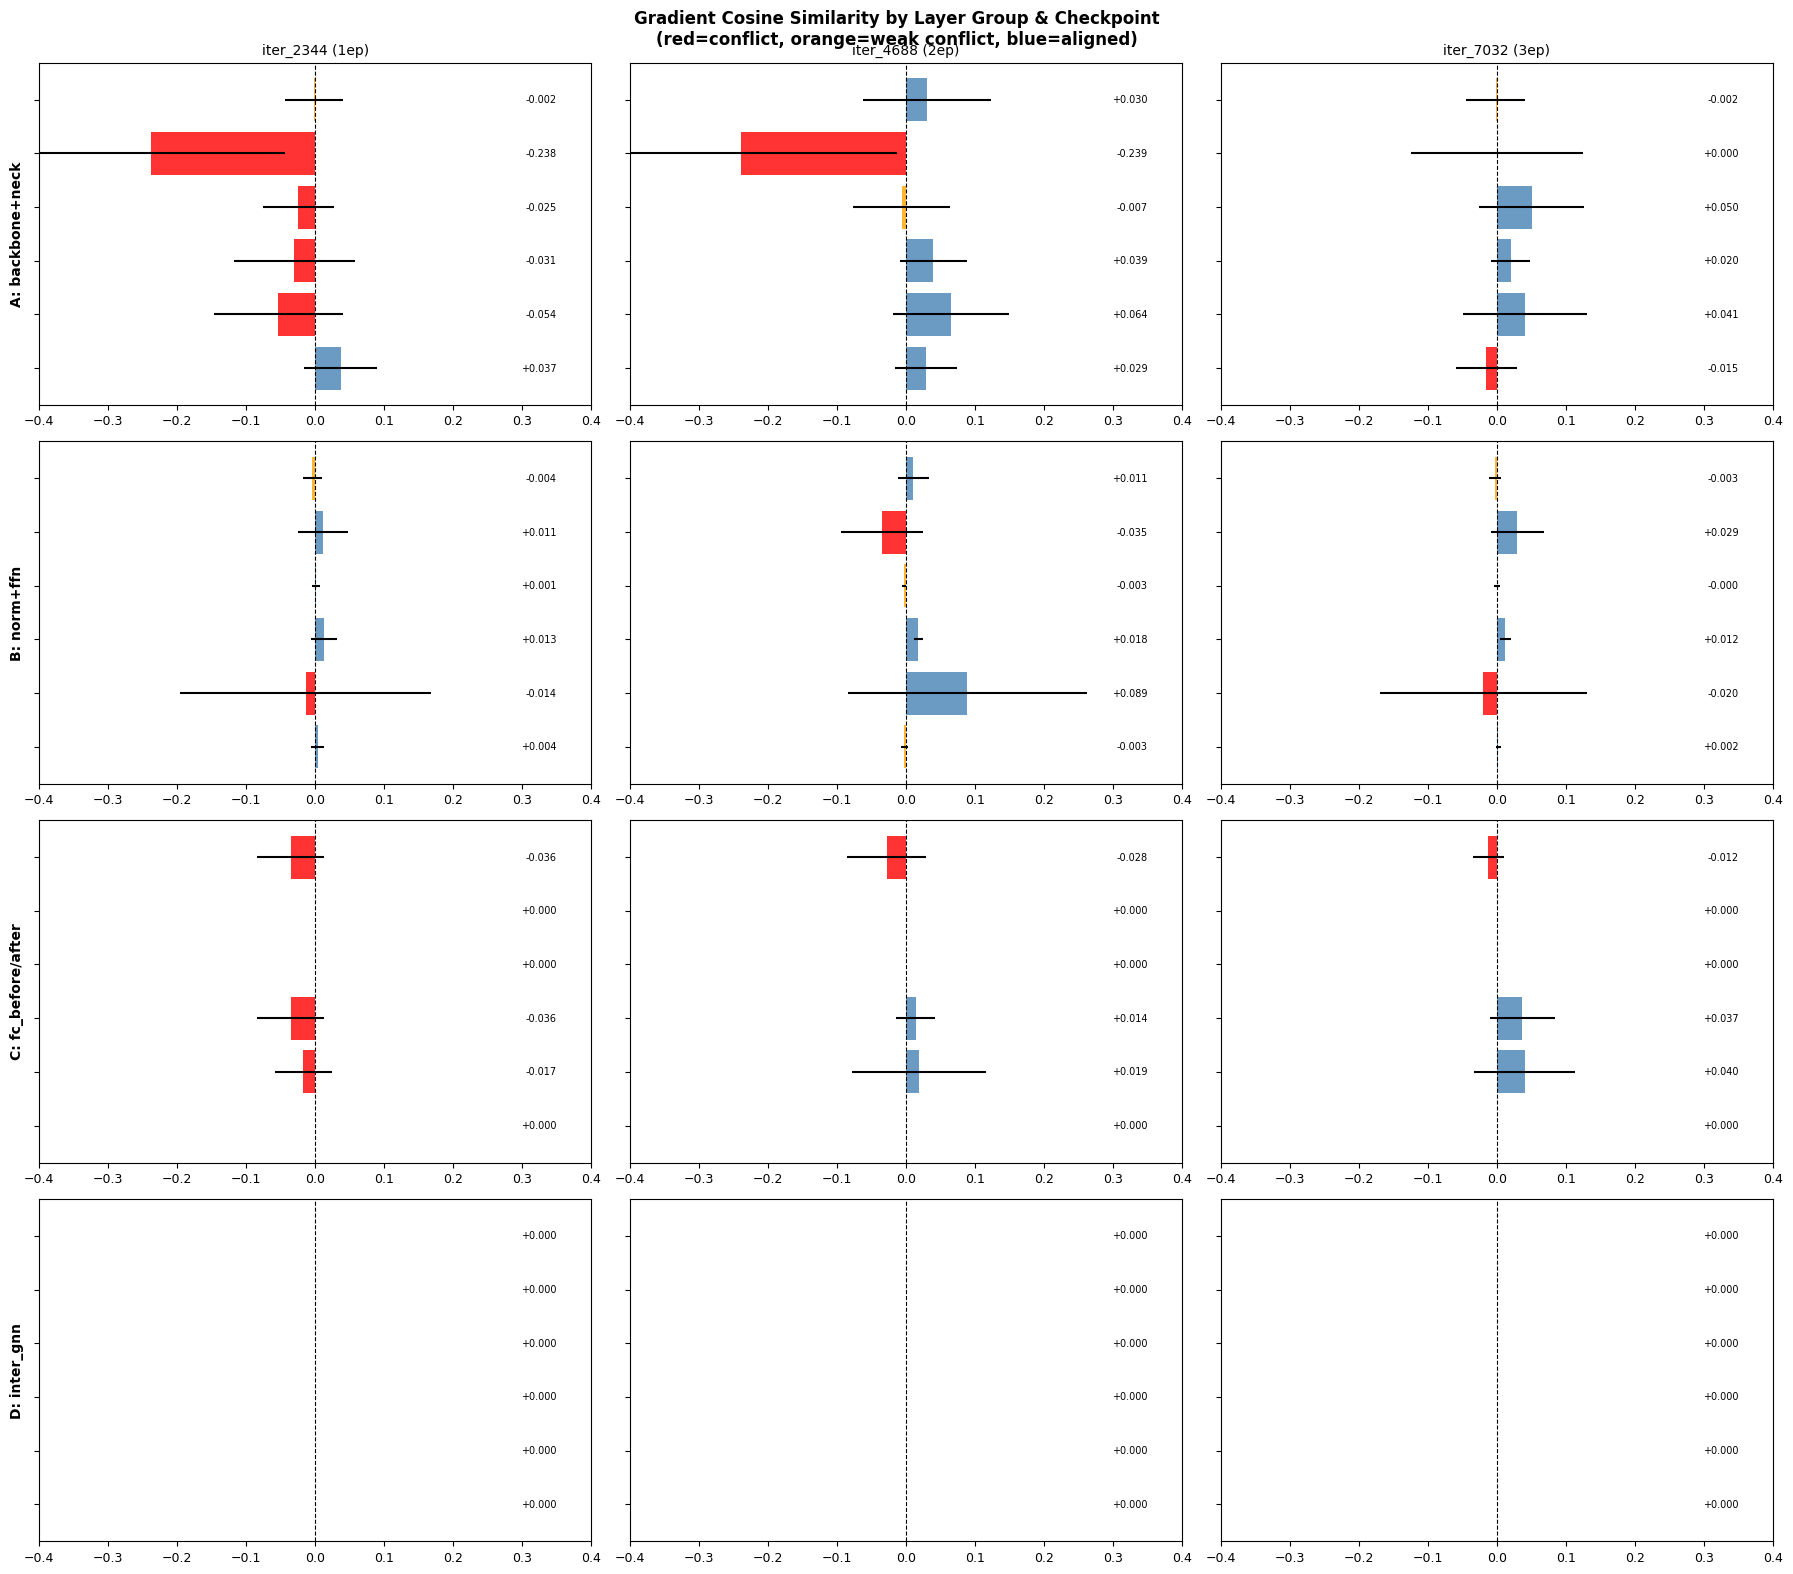

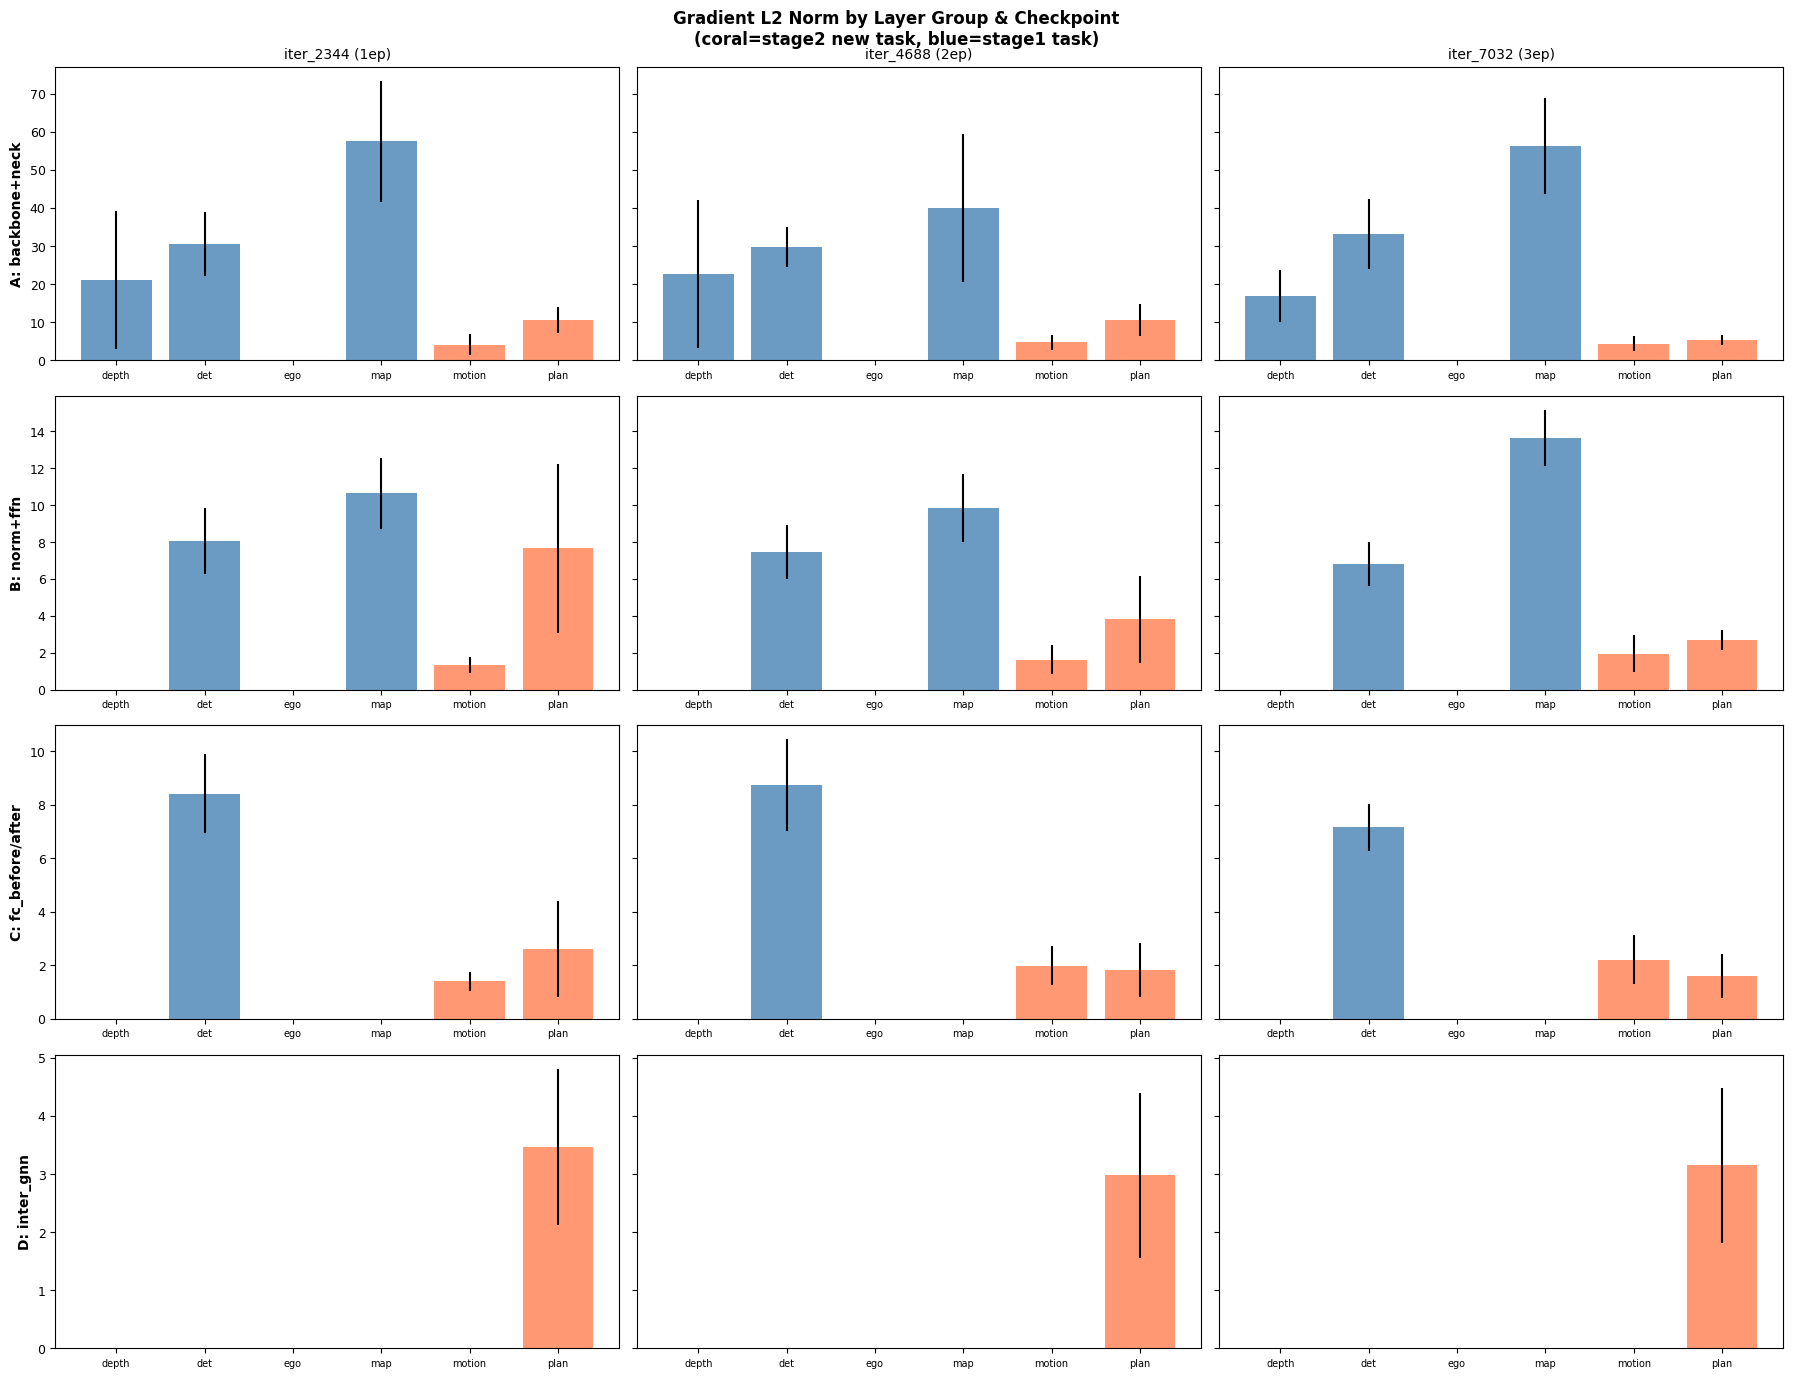

Saved: gradient_conflict_finegrained.png, gradient_norms_finegrained.png


In [14]:
# ============================================================
# 3-E. 전체 그룹 비교 시각화
# ============================================================
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['font.size'] = 9

all_results = {
    'A: backbone+neck': results_A,
    'B: norm+ffn': results_B,
    'C: fc_before/after': results_C,
    'D: inter_gnn': results_D,
}

# det 관련 conflict pairs만 추출 (det/map이 stage1에서 학습된 핵심 task)
FOCUS_PAIRS = [
    'det vs map', 'det vs motion', 'det vs plan',
    'map vs motion', 'map vs plan', 'motion vs plan',
]

fig, axes = plt.subplots(len(all_results), len(CKPT_ITERS), figsize=(18, 16),
                         sharey='row')

for row, (group_name, group_results) in enumerate(all_results.items()):
    for col, it in enumerate(CKPT_ITERS):
        ax = axes[row][col]
        cos_sims = group_results[it]['cos']

        pairs = [p for p in FOCUS_PAIRS if p in cos_sims]
        means = [np.mean(cos_sims[p]) for p in pairs]
        stds = [np.std(cos_sims[p]) for p in pairs]
        colors = ['red' if m < -0.01 else ('orange' if m < 0 else 'steelblue') for m in means]

        bars = ax.barh(range(len(pairs)), means, xerr=stds, color=colors, alpha=0.8)
        ax.set_yticks(range(len(pairs)))
        if col == 0:
            ax.set_yticklabels(pairs, fontsize=8)
        else:
            ax.set_yticklabels([])
        ax.axvline(x=0, color='black', linestyle='--', linewidth=0.8)
        ax.set_xlim(-0.4, 0.4)

        if row == 0:
            ax.set_title(f'iter_{it} ({it//2344}ep)', fontsize=10)
        if col == 0:
            ax.set_ylabel(group_name, fontsize=10, fontweight='bold')

        for i, (m, s) in enumerate(zip(means, stds)):
            ax.text(0.35, i, f'{m:+.3f}', va='center', fontsize=7, ha='right')

fig.suptitle('Gradient Cosine Similarity by Layer Group & Checkpoint\n'
             '(red=conflict, orange=weak conflict, blue=aligned)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(STAGE2_CKPT_DIR, 'gradient_conflict_finegrained.png'),
            dpi=150, bbox_inches='tight')
plt.show()

# --- Gradient Norm 비교 ---
fig2, axes2 = plt.subplots(len(all_results), len(CKPT_ITERS), figsize=(18, 14),
                           sharey='row')

for row, (group_name, group_results) in enumerate(all_results.items()):
    for col, it in enumerate(CKPT_ITERS):
        ax = axes2[row][col]
        grad_norms = group_results[it]['norms']
        tasks = sorted(grad_norms.keys())
        means = [np.mean(grad_norms[t]) for t in tasks]
        stds = [np.std(grad_norms[t]) for t in tasks]
        task_colors = ['coral' if t in ['motion', 'plan', 'ego'] else 'steelblue' for t in tasks]

        ax.bar(tasks, means, yerr=stds, color=task_colors, alpha=0.8)
        if row == 0:
            ax.set_title(f'iter_{it} ({it//2344}ep)', fontsize=10)
        if col == 0:
            ax.set_ylabel(group_name, fontsize=10, fontweight='bold')
        ax.tick_params(axis='x', labelsize=7)

fig2.suptitle('Gradient L2 Norm by Layer Group & Checkpoint\n'
              '(coral=stage2 new task, blue=stage1 task)',
              fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(STAGE2_CKPT_DIR, 'gradient_norms_finegrained.png'),
            dpi=150, bbox_inches='tight')
plt.show()

print("Saved: gradient_conflict_finegrained.png, gradient_norms_finegrained.png")